# 🏒 VIZER NHL — 04 · Scanner d'Inférence

Scan les matchs du jour, calcule les probabilités et détecte les value bets.

**Prérequis :** Avoir lancé les notebooks 01 → 02 → 03 dans l'ordre.

**Données nécessaires :**
- `vizer_master_model_v5.joblib` (bundle entraîné)
- `dataset_agrege_vizer_nhl.csv` (historique pour Elo et stats)
- Clé API The-Odds-API

In [1]:
import sys
print('▶ Chargement des modules...', flush=True)
sys.path.insert(0, '.')

# CRITIQUE : importer PlattCalibrator AVANT joblib.load
# joblib cherche la classe dans le namespace Python au moment du chargement
print('  → Import vizer_utils...', flush=True)
from vizer_utils import (
    PlattCalibrator,
    compute_elo_for_inference,
    get_latest_team_stats,
    compute_real_b2b,
    calculate_over_probability,
    build_input_vector,
    TEAM_TO_CODE,
    get_team_code,          # lookup robuste : gère accents, St./St, casse
    # Marchés étendus V5.5
    compute_p1_markets,
    compute_total_distribution,
    compute_goal_intervals,
    compute_top_exact_scores,
    compute_close_game_probability,
    # Gardien partant V5.5
    get_nhl_schedule,
    get_probable_starters,
    get_goalie_rolling_gsae,
    # V5.6 Améliorations
    calculate_over_probability_nb,
    compute_top_exact_scores_bivariate,
    bayesian_p1_winner,
    btts_p1_quality,
)

print('  → Imports standards...', flush=True)
import os, logging, warnings, time
import requests  # pour API The-Odds et NHL
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import poisson
from datetime import datetime
from IPython.display import display, HTML

os.environ['LIGHTGBM_VERBOSITY'] = '-1'
logging.getLogger('lightgbm').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

print('✅ Tous les imports OK — prêt pour la suite', flush=True)

▶ Chargement des modules...
  → Import vizer_utils...
  → Imports standards...
✅ Tous les imports OK — prêt pour la suite


## ⚙️ Configuration

In [2]:
# ── Paramètres stratégiques ────────────────────────────────────────────────────
ODDS_API_KEY          = 'aaea026bdcd560b9ab5f8119b39adb38'  # Remplace si besoin
BANKROLL              = 25000
KELLY_FRACTION        = 0.15    # Fraction Kelly (prudence : 15% du Kelly pur)
VALUE_EDGE_THRESHOLD  = 0.04    # Edge minimum de 4% pour parier
MIN_PROBA_WIN         = 0.52    # Confiance minimum de 52%
TOTAL_GOALS_THRESHOLD = 5.5     # Seuil Over/Under standard NHL

MASTER_FILE        = 'vizer_master_model_v5.joblib'
AGGREGATED_DB_FILE = 'dataset_agrege_vizer_nhl.csv'
PICKS_FILE         = 'picks_history.csv'

print(f'💰 Bankroll : {BANKROLL:,}F | Kelly fraction : {KELLY_FRACTION:.0%}')
print(f'🎯 Seuils : Edge ≥ {VALUE_EDGE_THRESHOLD:.0%} | Proba ≥ {MIN_PROBA_WIN:.0%} | Over/Under {TOTAL_GOALS_THRESHOLD}')

💰 Bankroll : 25,000F | Kelly fraction : 15%
🎯 Seuils : Edge ≥ 4% | Proba ≥ 52% | Over/Under 5.5


## 📦 Chargement du bundle et reconstruction des Elo

In [3]:
# Chargement du bundle
# PlattCalibrator est déjà dans le namespace → joblib peut le désérialiser
print(f'\n▶ Chargement du bundle depuis {MASTER_FILE}...')
try:
    bundle = joblib.load(MASTER_FILE)
    FEATURES = bundle['features']
    meta     = bundle.get('metadata', {})
    print(f'✅ Bundle V{meta.get("version","?")} chargé')
    print(f'   AUC : {meta.get("auc","?"):.4f} | Accuracy : {meta.get("accuracy","?"):.2%}')
    print(f'   Modèle principal : {meta.get("primary_model","?")} | Calibrateur : {meta.get("calibrator_type","?")}')
    print(f'   {len(FEATURES)} features | Entraîné le : {meta.get("train_date","?")}')
except Exception as e:
    print(f'❌ Erreur chargement bundle : {e}')
    raise

print('\n▶ Chargement base gardiens...')
# Chargement de la base gardiens rolling (pour lookup à l'inférence)
GOALIE_ROLLING_FILE = 'goalies_rolling_gsae.csv'
if os.path.exists(GOALIE_ROLLING_FILE):
    goalies_db = pd.read_csv(GOALIE_ROLLING_FILE)
    goalies_db['gameId'] = pd.to_numeric(goalies_db['gameId'], errors='coerce')
    print(f'\n✅ goalies_rolling_gsae.csv chargé : {len(goalies_db):,} entrées | {goalies_db["name"].nunique()} gardiens')
else:
    goalies_db = None
    print('\nℹ️  goalies_rolling_gsae.csv absent — diff_goalie_starter_gsae = 0 à l\'inférence')

print('\n▶ Chargement du dataset historique pour Elo...')
import numpy as np
db = pd.read_csv(AGGREGATED_DB_FILE).replace([np.inf, -np.inf], np.nan).fillna(0)
if 'gameDate_home' in db.columns:
    db = db.sort_values('gameDate_home')
print(f'   ✅ {len(db):,} matchs historiques chargés')

print('\n🏆 Reconstruction des Elo (calcul rapide sur historique)...')
elo_ratings = compute_elo_for_inference(db)
if elo_ratings:
    top5 = sorted(elo_ratings.items(), key=lambda x: -x[1])[:5]
    print(f'   Top 5 Elo : {[(t, f"{r:.0f}") for t, r in top5]}')


# Paramètres V5.6 depuis le bundle
nb_disp_h = bundle.get('metadata', {}).get('nb_dispersion_h', 1.0)
nb_disp_a = bundle.get('metadata', {}).get('nb_dispersion_a', 1.0)
bivariate_lambda3 = bundle.get('metadata', {}).get('bivariate_lambda3', 0.0)
ordinal_model = bundle.get('ordinal_model')

print(f'\n📊 Paramètres V5.6 :')
print(f'   NB dispersion : home={nb_disp_h:.3f} | away={nb_disp_a:.3f}')
print(f'   Bivariate λ_3 : {bivariate_lambda3:.4f}')
print(f'   Ordinal model : {"✅ disponible" if ordinal_model is not None else "❌ absent (fallback Poisson)"}')

# Chargement priors P1 par équipe (pour bayesian)
TEAM_PRIORS_FILE = 'team_p1_priors.csv'
if os.path.exists(TEAM_PRIORS_FILE):
    team_priors_df = pd.read_csv(TEAM_PRIORS_FILE)
    team_p1_priors_dict = team_priors_df.set_index('team').to_dict('index')
    print(f'   Team P1 priors : ✅ {len(team_p1_priors_dict)} équipes')
else:
    team_p1_priors_dict = {}
    print(f'   Team P1 priors : ❌ absent (fallback Poisson seul)')


▶ Chargement du bundle depuis vizer_master_model_v5.joblib...
✅ Bundle VV5.4 chargé
   AUC : 0.6098 | Accuracy : 58.60%
   Modèle principal : LGB | Calibrateur : temperature
   19 features | Entraîné le : 2026-05-16 20:06

▶ Chargement base gardiens...

ℹ️  goalies_rolling_gsae.csv absent — diff_goalie_starter_gsae = 0 à l'inférence

▶ Chargement du dataset historique pour Elo...
   ✅ 22,664 matchs historiques chargés

🏆 Reconstruction des Elo (calcul rapide sur historique)...
   Top 5 Elo : [('TBL', '1606'), ('COL', '1605'), ('CAR', '1603'), ('BUF', '1583'), ('DAL', '1572')]

📊 Paramètres V5.6 :
   NB dispersion : home=1.000 | away=1.000
   Bivariate λ_3 : 0.0000
   Ordinal model : ✅ disponible
   Team P1 priors : ✅ 32 équipes


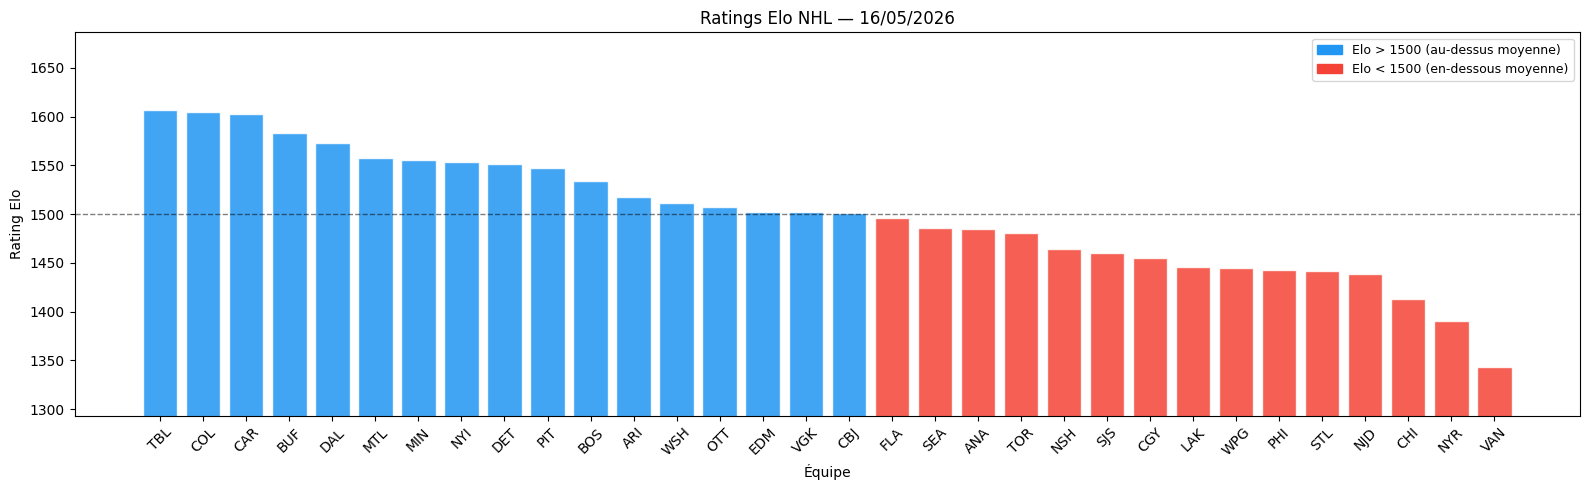

In [4]:
# Visualisation des ratings Elo
if elo_ratings:
    teams_sorted = sorted(elo_ratings.items(), key=lambda x: -x[1])
    teams_  = [t[0] for t in teams_sorted]
    ratings = [t[1] for t in teams_sorted]
    colors  = ['#2196F3' if r > 1500 else '#F44336' for r in ratings]

    fig, ax = plt.subplots(figsize=(16, 5))
    bars = ax.bar(teams_, ratings, color=colors, edgecolor='white', alpha=0.85)
    ax.axhline(1500, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Médiane (1500)')
    ax.set_xlabel('Équipe')
    ax.set_ylabel('Rating Elo')
    ax.set_title(f'Ratings Elo NHL — {datetime.now().strftime("%d/%m/%Y")}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.set_ylim(min(ratings) - 50, max(ratings) + 80)
    blue_p = mpatches.Patch(color='#2196F3', label='Elo > 1500 (au-dessus moyenne)')
    red_p  = mpatches.Patch(color='#F44336', label='Elo < 1500 (en-dessous moyenne)')
    ax.legend(handles=[blue_p, red_p], fontsize=9)
    plt.tight_layout()
    plt.savefig('elo_rankings.png', dpi=120, bbox_inches='tight')
    plt.show()

## 🔮 Fonctions de prédiction

In [5]:
def predict_game(bundle, db, h_code, a_code, elo_ratings, features, game_date=None, goalie_gsae_h=0.0, goalie_gsae_a=0.0):
    """Calcule toutes les prédictions pour un match donné."""
    h_stats = get_latest_team_stats(db, h_code)
    a_stats = get_latest_team_stats(db, a_code)
    if not h_stats or not a_stats:
        return None

    # Injection Elo courant
    h_stats['elo'] = elo_ratings.get(h_code, 1500.0)
    a_stats['elo'] = elo_ratings.get(a_code, 1500.0)
    # Injection GSAE gardien partant confirmé (ou 0 si inconnu)
    h_stats['goalie_starter_gsae'] = goalie_gsae_h
    a_stats['goalie_starter_gsae'] = goalie_gsae_a

    # B2B réel
    game_date_str = game_date or datetime.now().isoformat()
    b2b_h = compute_real_b2b(h_stats, game_date_str)
    b2b_a = compute_real_b2b(a_stats, game_date_str)

    # Vecteur de features
    input_dict = {feat: build_input_vector(feat, h_stats, a_stats, b2b_h, b2b_a)
                  for feat in features}

    # Transformation
    input_df     = pd.DataFrame([input_dict], columns=features).fillna(0.0)
    input_scaled = pd.DataFrame(bundle['scaler'].transform(input_df), columns=features)

    # Prédiction principale
    primary = bundle.get('primary_model') or bundle.get('lgb_model') or bundle.get('xgb_model')
    raw     = primary.predict_proba(input_scaled)[:, 1][0]
    p_win_h = float(bundle['calibrator'].predict([raw])[0])

    # Cross-check accord
    p_xgb       = bundle['xgb_model'].predict_proba(input_scaled)[:, 1][0]
    p_lgb       = bundle['lgb_model'].predict_proba(input_scaled)[:, 1][0]
    agree       = (p_xgb > 0.5) == (p_lgb > 0.5)

    # Poisson : prédiction brute puis correction multiplicative
    raw_h = bundle['model_home'].predict(input_scaled)[0]
    raw_a = bundle['model_away'].predict(input_scaled)[0]
    
    # Correction du drift par FACTEUR multiplicatif (préserve la variation entre matchs)
    # Bug V5.3 : raw * (mean / raw) = mean → tous les matchs prédisaient la même chose !
    # Fix V5.4 : raw * (constant_factor) → variation préservée, drift global corrigé
    factor_h = bundle['metadata'].get('poisson_correction_h', 1.0)
    factor_a = bundle['metadata'].get('poisson_correction_a', 1.0)
    raw_h = raw_h * factor_h
    raw_a = raw_a * factor_a
    
    # P1 dédié si disponible (sinon fallback approximation × 0.33 dans compute_p1_markets)
    has_p1 = bundle.get('has_p1_data', False) and bundle.get('model_home_p1') is not None
    if has_p1:
        raw_h_p1 = bundle['model_home_p1'].predict(input_scaled)[0]
        raw_a_p1 = bundle['model_away_p1'].predict(input_scaled)[0]
        fh_p1 = bundle['metadata'].get('poisson_correction_h_p1', 1.0)
        fa_p1 = bundle['metadata'].get('poisson_correction_a_p1', 1.0)
        lambda_p1_h_real = float(raw_h_p1 * fh_p1)
        lambda_p1_a_real = float(raw_a_p1 * fa_p1)
    else:
        lambda_p1_h_real = None
        lambda_p1_a_real = None

    p_over = calculate_over_probability(raw_h, raw_a, TOTAL_GOALS_THRESHOLD)

    return {
        'p_win_h':     p_win_h,
        'p_xgb':       p_xgb,
        'p_lgb':       p_lgb,
        'agree':       agree,
        'goals_h':     raw_h,
        'goals_a':     raw_a,
        'p_over':      p_over,
        'b2b_h':       b2b_h,
        'b2b_a':       b2b_a,
        'elo_h':       h_stats['elo'],
        'elo_a':       a_stats['elo'],
        'input_scaled': input_scaled,
        'lambda_p1_h_real': lambda_p1_h_real,
        'lambda_p1_a_real': lambda_p1_a_real,
        'h_stats': h_stats,       # exposés pour les marchés étendus (OT/SO features de parité)
        'a_stats': a_stats,
    }

print('✅ Fonctions de prédiction prêtes')

✅ Fonctions de prédiction prêtes


## 🏒 Scan des matchs du jour

In [6]:
print(f'\n{"═"*95}')
print(f' 🏒 VIZER ELITE SCANNER V5.3 — {datetime.now().strftime("%d/%m/%Y %H:%M")}')
print(f'{"═"*95}\n')

# Récupération des cotes
try:
    url = (f'https://api.the-odds-api.com/v4/sports/icehockey_nhl/odds/'
           f'?apiKey={ODDS_API_KEY}&regions=eu&markets=h2h,totals&oddsFormat=decimal')
    resp      = requests.get(url, timeout=15)
    odds_data = resp.json()
    print(f'✅ API The-Odds : {len(odds_data)} matchs récupérés')
    remaining = resp.headers.get('x-requests-remaining', '?')
    print(f'   Crédits API restants : {remaining}')
except Exception as e:
    print(f'❌ Erreur API : {e}')
    odds_data = []

# ── Résultats ─────────────────────────────────────────────────────────────────
all_results  = []
value_picks  = []
unmapped     = []  # équipes non reconnues par l'API

# === Récupération des partants probables via NHL API ===
# Une seule requête pour tous les matchs du jour (économise les appels)
print('\n▶ Interrogation NHL API pour gardiens partants...')
nhl_games   = get_nhl_schedule()   # matchs du jour avec gameId NHL
nhl_starters = {}                  # {(home_code, away_code): {home_goalie, away_goalie}}
if nhl_games:
    print(f'   {len(nhl_games)} matchs trouvés pour {datetime.now().strftime("%Y-%m-%d")}')
    for ng in nhl_games:
        if ng.get('gameId'):
            starters_info = get_probable_starters(ng['gameId'])
            if starters_info.get('confirmed'):
                key = (ng['home'], ng['away'])
                nhl_starters[key] = starters_info
                print(f'   ✓ {ng["home"]} vs {ng["away"]} : {starters_info["home_goalie"]} / {starters_info["away_goalie"]}')
    if not nhl_starters:
        print('   ℹ️  Partants pas encore annoncés (normal avant ~14h le jour du match)')
else:
    print('   ℹ️  Aucun match NHL trouvé via API (intersaison ou problème réseau)')

for game in odds_data:
    h_full = game['home_team']
    a_full = game['away_team']

    # get_team_code gère : accents (Montréal→MTL), St./St, casse
    h_code = get_team_code(h_full)
    a_code = get_team_code(a_full)

    if not h_code:
        unmapped.append(h_full)
        print(f'⚠️  Domicile non mappé : "{h_full}"')
        continue
    if not a_code:
        unmapped.append(a_full)
        print(f'⚠️  Extérieur non mappé : "{a_full}"')
        continue

    # Récupération du GSAE du gardien partant (NHL API ou fallback 0)
    starter_key = (h_code, a_code)
    starters_today = nhl_starters.get(starter_key, {})
    
    def _lookup_gsae(goalie_name, team, goalies_db):
        if goalies_db is None or not goalie_name:
            return 0.0
        recent = goalies_db[(goalies_db['name'] == goalie_name) & 
                            (goalies_db['team'] == team)].tail(10)
        return float(recent['goalie_gsae_rolling_10'].mean()) if len(recent) > 0 else 0.0
    
    goalie_gsae_h = _lookup_gsae(starters_today.get('home_goalie'), h_code, goalies_db)
    goalie_gsae_a = _lookup_gsae(starters_today.get('away_goalie'), a_code, goalies_db)
    
    pred = predict_game(bundle, db, h_code, a_code, elo_ratings, FEATURES,
                        game.get('commence_time'),
                        goalie_gsae_h=goalie_gsae_h, goalie_gsae_a=goalie_gsae_a)
    if not pred:
        continue

    p_win_h = pred['p_win_h']
    agree   = pred['agree']
    b2b_flags = ''
    if pred['b2b_h']: b2b_flags += ' ⚡DOM'
    if pred['b2b_a']: b2b_flags += ' ⚡EXT'
    conf_tag = '🟢 ACCORD' if agree else '🟡 désaccord'

    row = {
        'Domicile':   h_full, 'Extérieur': a_full,
        'P(Dom)':     f'{p_win_h:.1%}', 'P(Ext)': f'{1-p_win_h:.1%}',
        'Conf':       conf_tag,
        'Elo Dom':    f'{pred["elo_h"]:.0f}', 'Elo Ext': f'{pred["elo_a"]:.0f}',
        'Buts préd.': f'{pred["goals_h"]:.1f}–{pred["goals_a"]:.1f}',
        'P(Over 5.5)': f'{pred["p_over"]:.1%}',
        'B2B':         b2b_flags.strip(),
    }

    # Analyse value bets
    if game.get('bookmakers'):
        h2h    = next((m for m in game['bookmakers'][0]['markets'] if m['key'] == 'h2h'), None)
        totals = next((m for m in game['bookmakers'][0]['markets'] if m['key'] == 'totals'), None)

        if h2h:
            try:
                o_h = next(o['price'] for o in h2h['outcomes'] if o['name'] == h_full)
                o_a = next(o['price'] for o in h2h['outcomes'] if o['name'] == a_full)
                winner = h_full if p_win_h > 0.5 else a_full
                prob   = p_win_h if p_win_h > 0.5 else (1 - p_win_h)
                odd    = o_h if p_win_h > 0.5 else o_a
                edge   = prob - (1 / odd)
                kelly  = (prob * odd - 1) / (odd - 1) * BANKROLL * KELLY_FRACTION

                row['Cote H2H'] = f'{odd:.2f}'
                row['Edge H2H'] = f'{edge:+.1%}'

                if prob >= MIN_PROBA_WIN and edge >= VALUE_EDGE_THRESHOLD:
                    row['🔥 Value H2H'] = f'{winner} @{odd:.2f}  Mise:{kelly:.0f}F'
                    value_picks.append({
                        'date':     datetime.now().strftime('%Y-%m-%d'),
                        'match':    f'{h_full} vs {a_full}',
                        'type':     'H2H',
                        'pick':     winner,
                        'cote':     odd,
                        'edge':     edge,
                        'mise':     kelly,
                        'proba':    prob,
                        'accord':   agree,
                    })
            except Exception:
                pass

        if totals:
            try:
                o_over    = next(o['price'] for o in totals['outcomes']
                                 if o['name'] == 'Over' and o.get('point') == TOTAL_GOALS_THRESHOLD)
                edge_over = pred['p_over'] - (1 / o_over)
                kelly_ov  = (pred['p_over'] * o_over - 1) / (o_over - 1) * BANKROLL * KELLY_FRACTION

                row['Cote Over'] = f'{o_over:.2f}'
                row['Edge Over'] = f'{edge_over:+.1%}'

                if edge_over >= VALUE_EDGE_THRESHOLD:
                    row['💥 Value Over'] = f'Over {TOTAL_GOALS_THRESHOLD} @{o_over:.2f}  Mise:{kelly_ov:.0f}F'
                    value_picks.append({
                        'date':     datetime.now().strftime('%Y-%m-%d'),
                        'match':    f'{h_full} vs {a_full}',
                        'type':     'Over',
                        'pick':     f'Over {TOTAL_GOALS_THRESHOLD}',
                        'cote':     o_over,
                        'edge':     edge_over,
                        'mise':     kelly_ov,
                        'proba':    pred['p_over'],
                        'accord':   agree,
                    })
            except Exception:
                pass

    all_results.append(row)
    time.sleep(0.2)

if unmapped:
    print(f'\n⚠️  Équipes non mappées (ajoute dans vizer_utils.TEAM_TO_CODE) : {set(unmapped)}')
print(f'\n{"═"*65}')
print(f' 📋 BILAN DU SCAN :')
print(f'    • Matchs analysés   : {len(all_results)}')
print(f'    • Value bets H2H/Over : {len(value_picks)}')
print(f'    • Partants confirmés : {len(nhl_starters)}/{len(odds_data) if odds_data else 0}')
if len(all_results) == 0:
    print(f'\n ⚠️  Aucun match analysé. Causes possibles :')
    print(f'    - Pas de matchs NHL aujourd\'hui (intersaison ?)')
    print(f'    - API The-Odds : crédits épuisés ou clé invalide')
    print(f'    - Toutes les équipes non mappées dans TEAM_TO_CODE')
elif len(value_picks) == 0:
    print(f'\n ℹ️  Aucun value bet détecté avec les seuils actuels :')
    print(f'    - Edge minimum : {VALUE_EDGE_THRESHOLD:.0%}')
    print(f'    - Proba minimum : {MIN_PROBA_WIN:.0%}')
    print(f'    Les tableaux ci-dessous afficheront tous les matchs scannés.')
print(f'{"═"*65}')


═══════════════════════════════════════════════════════════════════════════════════════════════
 🏒 VIZER ELITE SCANNER V5.3 — 16/05/2026 20:06
═══════════════════════════════════════════════════════════════════════════════════════════════

✅ API The-Odds : 2 matchs récupérés
   Crédits API restants : 445

▶ Interrogation NHL API pour gardiens partants...
⚠️  NHL API schedule erreur : HTTPSConnectionPool(host='api-web.nhle.com', port=443): Max retries exceeded with url: /v1/schedule/2026-05-16 (Caused by NameResolutionError("HTTPSConnection(host='api-web.nhle.com', port=443): Failed to resolve 'api-web.nhle.com' ([Errno -2] Name or service not known)"))
   ℹ️  Aucun match NHL trouvé via API (intersaison ou problème réseau)

═════════════════════════════════════════════════════════════════
 📋 BILAN DU SCAN :
    • Matchs analysés   : 2
    • Value bets H2H/Over : 2
    • Partants confirmés : 0/2
═════════════════════════════════════════════════════════════════


## 📋 Résultats — Tableau complet

In [7]:
if all_results:
    df_display = pd.DataFrame(all_results)

    # Style HTML coloré
    def style_row(row):
        styles = [''] * len(row)
        if '🔥' in str(row.get('🔥 Value H2H', '')):
            styles = ['background-color: #fff3e0'] * len(row)
        if '💥' in str(row.get('💥 Value Over', '')):
            styles = ['background-color: #fce4ec'] * len(row)
        return styles

    cols_to_show = ['Domicile', 'Extérieur', 'P(Dom)', 'P(Ext)', 'Conf',
                    'Buts préd.', 'P(Over 5.5)', 'Elo Dom', 'Elo Ext']
    cols_existing = [c for c in cols_to_show if c in df_display.columns]

    display(HTML('<h3 style="color:#1565C0">📊 Prédictions du jour</h3>'))
    display(df_display[cols_existing].style
            .apply(style_row, axis=1)
            .hide(axis='index')
            .set_caption(f'VIZER V5.3 — {datetime.now().strftime("%d/%m/%Y %H:%M")}')
            .set_properties(**{'font-size': '12px', 'border': '1px solid #ddd'}))
else:
    display(HTML('<div style="background:#fff3cd;padding:12px;border-radius:6px">'
                 '<b>⚠️ Aucun match scanné</b><br>'
                 'Vérifie ta clé API The-Odds, ta connexion, ou bien il n\'y a simplement pas de matchs NHL aujourd\'hui.'
                 '</div>'))

Domicile,Extérieur,P(Dom),P(Ext),Conf,Buts préd.,P(Over 5.5),Elo Dom,Elo Ext
Montréal Canadiens,Buffalo Sabres,45.3%,54.7%,🟢 ACCORD,3.2–3.0,58.5%,1558,1583
Colorado Avalanche,Vegas Golden Knights,49.9%,50.1%,🟡 désaccord,3.5–3.0,61.7%,1605,1502


## 🔥 Value Bets détectés

In [8]:
if value_picks:
    df_picks = pd.DataFrame(value_picks)

    def color_pick(val):
        if isinstance(val, float):
            if val > 0.08: return 'background-color: #c8e6c9; font-weight: bold'
            if val > 0.04: return 'background-color: #fff9c4'
        return ''

    display(HTML('<h3 style="color:#B71C1C">🔥 VALUE BETS — Action recommandée</h3>'))
    display(df_picks[['match','type','pick','cote','proba','edge','mise','accord']]
            .rename(columns={'match':'Match','type':'Type','pick':'Pari',
                             'cote':'Cote','proba':'Proba','edge':'Edge',
                             'mise':'Mise (F)','accord':'XGB≡LGB'})
            .style
            .format({'Proba': '{:.1%}', 'Edge': '{:+.1%}', 'Cote': '{:.2f}',
                     'Mise (F)': '{:.0f}'})
            .map(color_pick, subset=['Edge'])
            .hide(axis='index'))

    # Sauvegarde dans l'historique
    PICKS_REQUIRED_COLS = ['date','match','type','pick','cote','edge','mise','proba','accord']
    if os.path.exists(PICKS_FILE):
        existing = pd.read_csv(PICKS_FILE)
        # Réinitialiser si format incompatible
        if not all(c in existing.columns for c in PICKS_REQUIRED_COLS):
            existing = pd.DataFrame(columns=PICKS_REQUIRED_COLS)
        combined = pd.concat([existing, df_picks], ignore_index=True).drop_duplicates(
            subset=['date','match','type'], keep='last')
    else:
        combined = df_picks
    combined.to_csv(PICKS_FILE, index=False)
    print(f'\n✅ {len(df_picks)} picks ajoutés → {PICKS_FILE} (total : {len(combined)} picks historiques)')
    # Affichage recap du jour
    display(HTML(f'<p><b>Récap du {datetime.now().strftime("%d/%m/%Y")} :</b> {len(df_picks)} value bets — mise totale : {df_picks["mise"].sum():.0f}F</p>'))
else:
    print(f'Aucun value bet détecté le {datetime.now().strftime("%d/%m/%Y")} (edge < {VALUE_EDGE_THRESHOLD:.0%} ou proba < {MIN_PROBA_WIN:.0%}).')

Match,Type,Pari,Cote,Proba,Edge,Mise (F),XGB≡LGB
Montréal Canadiens vs Buffalo Sabres,H2H,Buffalo Sabres,3.35,54.7%,+24.8%,1328,True
Colorado Avalanche vs Vegas Golden Knights,Over,Over 5.5,1.76,61.7%,+4.9%,428,False



✅ 2 picks ajoutés → picks_history.csv (total : 8 picks historiques)


## 📈 Historique des picks

📋 Historique : 8 picks au total


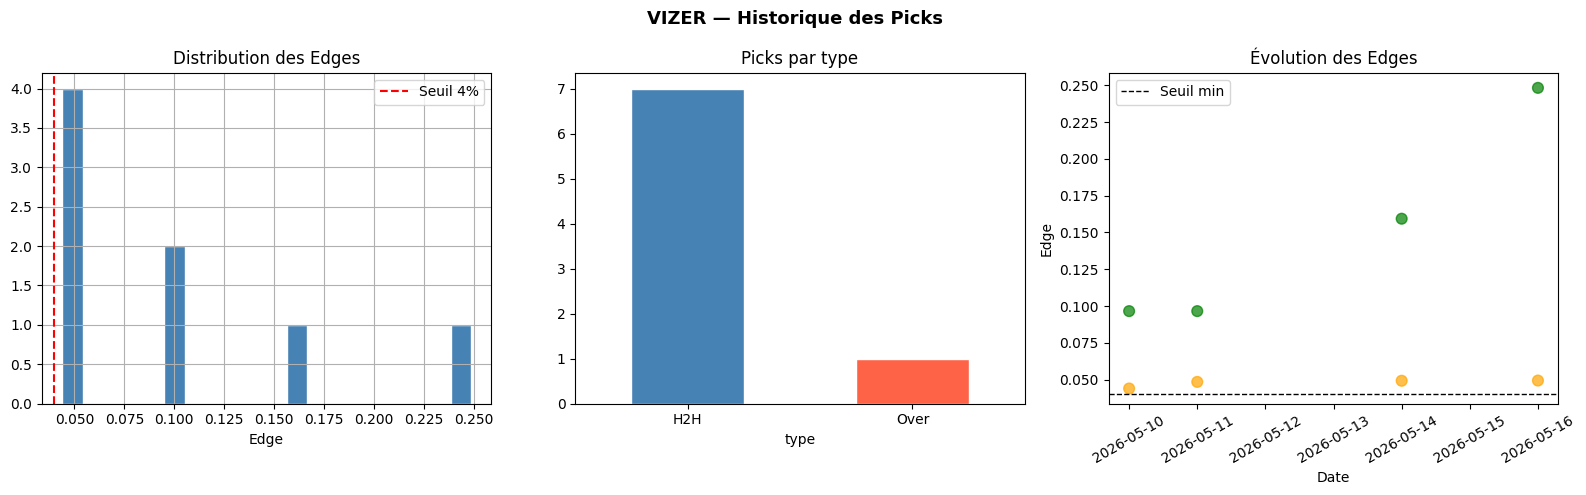

Métrique,Valeur
Total picks,8
Edge moyen,9.89%
Edge max,24.84%
Edge min,4.39%
Cote moyenne,2.21
Mise totale (F),5276
Picks H2H,7
Picks Over,1
Accord XGB+LGB,88%


In [9]:
PICKS_REQUIRED_COLS = ['date','match','type','pick','cote','edge','mise','proba','accord']

if os.path.exists(PICKS_FILE):
    hist = pd.read_csv(PICKS_FILE)
    # Vérifier que le fichier a le bon format (colonnes correctes)
    missing_cols = [c for c in PICKS_REQUIRED_COLS if c not in hist.columns]
    if missing_cols:
        print(f'⚠️  picks_history.csv incompatible (colonnes manquantes : {missing_cols})')
        print('   Format ancien détecté — réinitialisation du fichier.')
        os.remove(PICKS_FILE)
        hist = pd.DataFrame(columns=PICKS_REQUIRED_COLS)
    else:
        hist['date'] = pd.to_datetime(hist['date'])
    print(f'📋 Historique : {len(hist)} picks au total')

    if len(hist) >= 3:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle('VIZER — Historique des Picks', fontsize=13, fontweight='bold')

        # Distribution edges
        ax = axes[0]
        hist['edge'].hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
        ax.axvline(VALUE_EDGE_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                   label=f'Seuil {VALUE_EDGE_THRESHOLD:.0%}')
        ax.set_title('Distribution des Edges')
        ax.set_xlabel('Edge')
        ax.legend()

        # Picks par type
        ax = axes[1]
        type_counts = hist['type'].value_counts()
        type_counts.plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
        ax.set_title('Picks par type')
        ax.tick_params(axis='x', rotation=0)

        # Évolution des edges dans le temps
        ax = axes[2]
        hist_sorted = hist.sort_values('date')
        ax.scatter(hist_sorted['date'], hist_sorted['edge'],
                   c=['green' if e > 0.08 else 'orange' if e > 0.04 else 'red'
                      for e in hist_sorted['edge']],
                   alpha=0.7, s=60)
        ax.axhline(VALUE_EDGE_THRESHOLD, color='black', linestyle='--',
                   linewidth=1, label=f'Seuil min')
        ax.set_title('Évolution des Edges')
        ax.set_xlabel('Date')
        ax.set_ylabel('Edge')
        ax.tick_params(axis='x', rotation=30)
        ax.legend()

        plt.tight_layout()
        plt.savefig('picks_history.png', dpi=120, bbox_inches='tight')
        plt.show()

    # Résumé statistique — guard contre DataFrame vide
    if len(hist) == 0:
        display(HTML('<p style="color:#888;font-style:italic">📋 Historique vide — les picks apparaîtront ici après le premier scan avec value bets.</p>'))
    else:
        n = len(hist)
        summary = {
            'Total picks':     n,
            'Edge moyen':      f'{hist["edge"].mean():.2%}',
            'Edge max':        f'{hist["edge"].max():.2%}',
            'Edge min':        f'{hist["edge"].min():.2%}',
            'Cote moyenne':    f'{hist["cote"].mean():.2f}',
            'Mise totale (F)': f'{hist["mise"].sum():.0f}',
            'Picks H2H':       str((hist['type']=='H2H').sum()),
            'Picks Over':      str((hist['type']=='Over').sum()),
            'Accord XGB+LGB':  f'{hist["accord"].sum()/n:.0%}',
        }
        df_sum = pd.DataFrame(list(summary.items()), columns=['Métrique', 'Valeur'])
        display(df_sum.style.hide(axis='index'))
else:
    print('Pas encore d\'historique — les picks seront enregistrés lors de la première exécution.')

## 🔬 Analyse détaillée d'un match

## 🎲 Marchés étendus — P1, Total exact, Score exact

Pour chaque match scanné, calcule 3 marchés supplémentaires :
- **Période 1** : vainqueur P1, Over 1.5 P1, BTTS P1 (Poisson P1 dédié si disponible, sinon approximation λ_total × 0.30)
- **Total exact** : distribution exacte du nombre de buts + intervalles (0-2 / 3-4 / 5-6 / 7-8 / 9+)
- **Score exact** : top-5 des scores les plus probables avec cote équitable

In [10]:
# Calcul des marchés étendus pour tous les matchs scannés aujourd'hui
extended_results = []

# Réutiliser nhl_starters de la cellule scan (avec protection si pas exécutée)
try:
    nhl_starters
except NameError:
    nhl_starters = {}
    print('⚠️  nhl_starters absent — exécute d\'abord la cellule de scan principal')

def _lookup_gsae_ext(goalie_name, team, goalies_db):
    if goalies_db is None or not goalie_name:
        return 0.0
    recent = goalies_db[(goalies_db['name'] == goalie_name) & 
                        (goalies_db['team'] == team)].tail(10)
    return float(recent['goalie_gsae_rolling_10'].mean()) if len(recent) > 0 else 0.0

for game in odds_data:
    h_full = game['home_team']
    a_full = game['away_team']
    h_code = get_team_code(h_full)
    a_code = get_team_code(a_full)
    if not h_code or not a_code:
        continue

    # Récupération du GSAE gardien partant
    starters_today = nhl_starters.get((h_code, a_code), {})
    g_gsae_h = _lookup_gsae_ext(starters_today.get('home_goalie'), h_code, goalies_db)
    g_gsae_a = _lookup_gsae_ext(starters_today.get('away_goalie'), a_code, goalies_db)

    pred = predict_game(bundle, db, h_code, a_code, elo_ratings, FEATURES,
                        game.get('commence_time'),
                        goalie_gsae_h=g_gsae_h, goalie_gsae_a=g_gsae_a)
    if not pred:
        continue

    lam_h, lam_a = pred['goals_h'], pred['goals_a']

    # === 1. Période 1 — Poisson dédié si dispo, sinon approximation ===
    if pred.get('lambda_p1_h_real') is not None:
        l1_h, l1_a = pred['lambda_p1_h_real'], pred['lambda_p1_a_real']
        from scipy.stats import poisson as _poi
        p_h_nogoal = _poi.pmf(0, l1_h)
        p_a_nogoal = _poi.pmf(0, l1_a)
        p1 = {
            'lambda_p1_h':    l1_h,
            'lambda_p1_a':    l1_a,
            'p_btts_p1':      float((1 - p_h_nogoal) * (1 - p_a_nogoal)),
            'p_home_lead_p1': float(sum(_poi.pmf(i, l1_h) * _poi.pmf(j, l1_a)
                                        for i in range(8) for j in range(i))),
            'p_tied_p1':      float(sum(_poi.pmf(i, l1_h) * _poi.pmf(i, l1_a) for i in range(8))),
            'p_away_lead_p1': float(sum(_poi.pmf(i, l1_h) * _poi.pmf(j, l1_a)
                                        for j in range(8) for i in range(j))),
            'p_over_1_5_p1':  float(sum(_poi.pmf(i, l1_h) * _poi.pmf(j, l1_a)
                                        for i in range(8) for j in range(8) if i+j > 1.5)),
            'p_over_2_5_p1':  float(sum(_poi.pmf(i, l1_h) * _poi.pmf(j, l1_a)
                                        for i in range(8) for j in range(8) if i+j > 2.5)),
            'source': 'P1 Poisson dédié',
        }
    else:
        p1 = compute_p1_markets(lam_h, lam_a)
        p1['source'] = 'approximation λ×0.30'

    # === 2. Total exact + intervalles ===
    intervals = compute_goal_intervals(lam_h, lam_a)
    total_dist = compute_total_distribution(lam_h, lam_a, max_k=10)
    most_likely_total = max(total_dist, key=total_dist.get)

    # === 3. Score exact V5.6 — Bivariate Poisson si lambda3 > 0.05 ===
    if bivariate_lambda3 > 0.05:
        top_scores = compute_top_exact_scores_bivariate(lam_h, lam_a, bivariate_lambda3, top_n=5)
        score_method = 'Bivariate Poisson'
    else:
        top_scores = compute_top_exact_scores(lam_h, lam_a, top_n=5)
        score_method = 'Indépendance (λ_3 trop faible)'

    # === 4. Over/Under V5.6 — Negative Binomial ===
    p_over_nb = calculate_over_probability_nb(lam_h, lam_a, threshold=5.5,
                                                dispersion_h=nb_disp_h, dispersion_a=nb_disp_a)
    p_over_poisson = pred['p_over']

    # === 5. Intervalles V5.6 — Ordinal Regression ===
    if ordinal_model is not None:
        interval_probs_ord = ordinal_model.predict_proba(pred['input_scaled'])[0]
        interval_labels = ['0-2 buts', '3-4 buts', '5-6 buts', '7-8 buts', '9+ buts']
        intervals_ord = {lbl: float(p) for lbl, p in zip(interval_labels, interval_probs_ord)}
    else:
        intervals_ord = None

    # === 6. Bayesian P1 ===
    if team_p1_priors_dict and p1.get('source') == 'P1 Poisson dédié':
        bayes_p1 = bayesian_p1_winner(
            p1['lambda_p1_h'], p1['lambda_p1_a'],
            team_h_prior=team_p1_priors_dict.get(h_code),
            team_a_prior=team_p1_priors_dict.get(a_code)
        )
    else:
        bayes_p1 = None

    # === 7. Qualité BTTS P1 ===
    btts_qual, btts_warn = btts_p1_quality(p1['lambda_p1_h'], p1['lambda_p1_a'])

    extended_results.append({
        'match':              f'{h_code} vs {a_code}',
        'home':               h_full,
        'away':               a_full,
        'p1':                 p1,
        'intervals':          intervals,
        'intervals_ord':      intervals_ord,
        'most_likely_total':  most_likely_total,
        'p_most_likely':      total_dist[most_likely_total],
        'top_scores':         top_scores,
        'score_method':       score_method,
        'p_over_nb':          p_over_nb,
        'p_over_poisson':     p_over_poisson,
        'bayes_p1':           bayes_p1,
        'btts_qual':          btts_qual,
        'btts_warn':          btts_warn,
        'lambda_h':           lam_h,
        'lambda_a':           lam_a,
    })

print(f'✅ {len(extended_results)} matchs traités pour les marchés étendus V5.6')

✅ 2 matchs traités pour les marchés étendus V5.6


### 🥇 Période 1 — 3 marchés combinés

Approximation : la P1 contient ~33% des buts du match. Plus précis avec un modèle Poisson P1 dédié (futur).

In [11]:
if extended_results:
    df_p1 = pd.DataFrame([{
        'Match':         f'{r["home"][:20]} vs {r["away"][:20]}',
        'λ P1 (h-a)':    f'{r["p1"]["lambda_p1_h"]:.2f}-{r["p1"]["lambda_p1_a"]:.2f}',
        'Dom mène':      f'{r["p1"]["p_home_lead_p1"]:.1%}',
        'Égalité':       f'{r["p1"]["p_tied_p1"]:.1%}',
        'Ext mène':      f'{r["p1"]["p_away_lead_p1"]:.1%}',
        'Over 1.5':      f'{r["p1"]["p_over_1_5_p1"]:.1%}',
        'BTTS P1':       f'{r["p1"]["p_btts_p1"]:.1%}',
        'BTTS Qualité':  r.get('btts_qual', '?'),
        'Source':        r['p1'].get('source', '?'),
    } for r in extended_results])

    def color_source(val):
        if 'dédié' in str(val): return 'background-color:#e8f5e9;font-weight:bold'
        if 'approx' in str(val): return 'background-color:#fff3cd'
        return ''
    def color_btts_qual(val):
        if '⚠️' in str(val): return 'background-color:#ffcdd2'
        if '🟡' in str(val): return 'background-color:#fff9c4'
        if '✅' in str(val): return 'background-color:#c8e6c9'
        return ''
    n_real = sum(1 for r in extended_results if 'dédié' in r['p1'].get('source',''))
    src_lbl = '🎯 Poisson P1 dédié' if n_real==len(extended_results) else f'⚠️ mix ({n_real}/{len(extended_results)} dédié)'
    display(HTML(f'<h4 style="color:#1565C0">🥇 Marchés Période 1 — {src_lbl}</h4>'))
    display(df_p1.style.map(color_source, subset=['Source']).map(color_btts_qual, subset=['BTTS Qualité']).hide(axis='index'))
else:
    print('ℹ️  Pas de matchs scannés — les marchés étendus seront vides.')

Match,λ P1 (h-a),Dom mène,Égalité,Ext mène,Over 1.5,BTTS P1,BTTS Qualité,Source
Montréal Canadiens vs Buffalo Sabres,0.88-0.79,35.3%,34.5%,30.2%,49.5%,31.8%,🟡 Modéré,P1 Poisson dédié
Colorado Avalanche vs Vegas Golden Knights,0.97-0.79,38.6%,33.2%,28.3%,52.4%,33.8%,🟡 Modéré,P1 Poisson dédié


### 🧠 Bayesian P1 — avec confiance par match

Combine Poisson P1 avec priors historiques par équipe. La colonne **Confiance** indique la fiabilité (🟢 = forte, basée sur >100 matchs historiques).

In [12]:
# Affichage Bayesian P1 — uniquement si des priors team sont disponibles
if extended_results and any(r.get('bayes_p1') for r in extended_results):
    rows_bayes = []
    for r in extended_results:
        bp = r.get('bayes_p1')
        if bp is None:
            continue
        conf_tag = ('🟢 Élevée' if bp['confidence'] > 0.7
                    else '🟡 Modérée' if bp['confidence'] > 0.4
                    else '⚪ Faible')
        rows_bayes.append({
            'Match':          f'{r["home"][:20]} vs {r["away"][:20]}',
            'Dom mène (Bayes)': f'{bp["p_home_lead"]:.1%}',
            'Égalité (Bayes)':  f'{bp["p_tied"]:.1%}',
            'Ext mène (Bayes)': f'{bp["p_away_lead"]:.1%}',
            'Confiance':        conf_tag,
        })
    if rows_bayes:
        df_bayes = pd.DataFrame(rows_bayes)
        def color_conf(v):
            if '🟢' in str(v): return 'background-color:#c8e6c9;font-weight:bold'
            if '🟡' in str(v): return 'background-color:#fff9c4'
            return 'background-color:#f5f5f5'
        display(HTML('<h4 style="color:#1565C0">🧠 P1 Vainqueur — Bayesian avec niveau de confiance</h4>'))
        display(df_bayes.style.map(color_conf, subset=['Confiance']).hide(axis='index'))
        display(HTML('<div style="font-size:11px;color:#666">💡 Stratégie : ne parier que sur les matchs 🟢 Élevée.</div>'))
else:
    print('ℹ️  Bayesian P1 indisponible (pas de team_p1_priors.csv ou Poisson P1 absent)')

Match,Dom mène (Bayes),Égalité (Bayes),Ext mène (Bayes),Confiance
Montréal Canadiens vs Buffalo Sabres,33.3%,36.9%,29.9%,🟢 Élevée
Colorado Avalanche vs Vegas Golden Knights,36.6%,30.9%,32.5%,🟢 Élevée


### 🎯 Nombre exact de buts + Intervalles

Le nombre le plus probable et la probabilité par intervalle.

In [13]:
if extended_results:
    rows = []
    for r in extended_results:
        row = {'Match': f'{r["home"][:20]} vs {r["away"][:20]}',
               'Plus probable': f'{r["most_likely_total"]} buts ({r["p_most_likely"]:.1%})'}
        # V5.6 : préférer ordinal regression si disponible
        intervals_to_show = r.get('intervals_ord') or r['intervals']
        for label, p in intervals_to_show.items():
            row[label] = f'{p:.1%}'
        rows.append(row)
    df_int = pd.DataFrame(rows)

    def color_interval(val):
        try:
            pct = float(val.replace('%','')) / 100
            if pct > 0.35: return 'background-color: #c8e6c9; font-weight: bold'
            if pct > 0.25: return 'background-color: #fff9c4'
        except: pass
        return ''

    display(HTML('<h4 style="color:#1565C0">🎯 Nombre de buts — intervalles</h4>'))
    intervals_cols = ['0-2 buts','3-4 buts','5-6 buts','7-8 buts','9+ buts']
    display(df_int.style.map(color_interval, subset=intervals_cols).hide(axis='index'))

Match,Plus probable,0-2 buts,3-4 buts,5-6 buts,7-8 buts,9+ buts
Montréal Canadiens vs Buffalo Sabres,6 buts (16.0%),6.0%,24.2%,33.6%,23.4%,12.8%
Colorado Avalanche vs Vegas Golden Knights,6 buts (15.9%),6.2%,23.5%,33.8%,23.5%,13.0%


### 🎰 Score exact — Top 5 par match

Probabilité de chaque score (h-a) et la cote équitable correspondante. Cherche les bookmakers qui proposent une cote ≤ 0.7× la cote équitable.

In [14]:
if extended_results:
    for r in extended_results:
        display(HTML(f'<h4 style="color:#1565C0">🎰 {r["home"]} vs {r["away"]} — Top 5 scores exacts</h4>'))
        df_sc = pd.DataFrame([
            {'Score (Dom-Ext)': s[0], 'Probabilité': f'{s[1]:.1%}', 'Cote équitable': f'{s[2]:.1f}'}
            for s in r['top_scores']
        ])
        display(df_sc.style.hide(axis='index'))

Score (Dom-Ext),Probabilité,Cote équitable
3-3,5.0%,20.0
3-2,5.0%,20.2
2-3,4.7%,21.2
2-2,4.7%,21.3
4-3,4.0%,25.2


Score (Dom-Ext),Probabilité,Cote équitable
3-2,4.9%,20.2
3-3,4.9%,20.6
2-2,4.3%,23.3
4-2,4.3%,23.4
2-3,4.2%,23.7


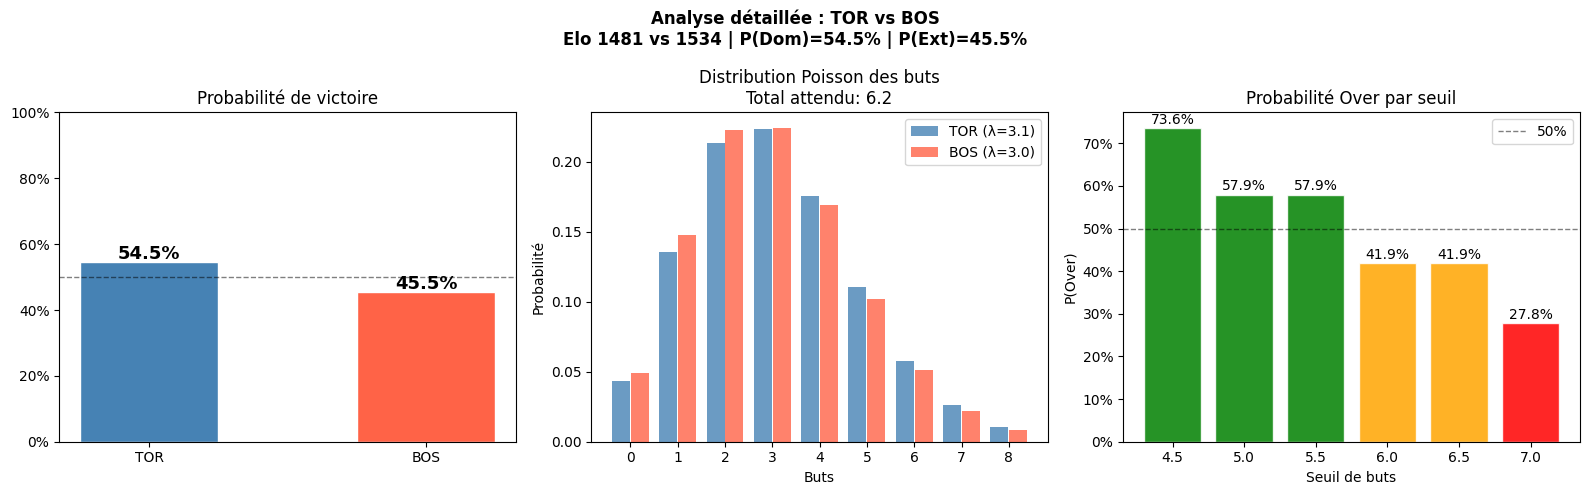


📊 Résumé : TOR vs BOS  [🟡 désaccord XGB/LGB]
   Proba : Dom 54.5% | Ext 45.5%
   Buts  : 3.1 – 3.0 (total 6.2)
   P(Over 5.5) : 57.9%


In [15]:
# Modifie ces codes pour analyser un match spécifique
HOME_CODE = 'TOR'  # Ex: TOR, MTL, EDM, TBL...
AWAY_CODE = 'BOS'

pred = predict_game(bundle, db, HOME_CODE, AWAY_CODE, elo_ratings, FEATURES)

if pred:
    p_h = pred['p_win_h']
    lh  = pred['goals_h']
    la  = pred['goals_a']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Analyse détaillée : {HOME_CODE} vs {AWAY_CODE}\n'
                 f'Elo {pred["elo_h"]:.0f} vs {pred["elo_a"]:.0f} | '
                 f'P(Dom)={p_h:.1%} | P(Ext)={1-p_h:.1%}',
                 fontsize=12, fontweight='bold')

    # 1. Probabilités victoire
    ax = axes[0]
    bars = ax.bar([HOME_CODE, AWAY_CODE], [p_h, 1-p_h],
                  color=['steelblue','tomato'], edgecolor='white', width=0.5)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
    for bar, val in zip(bars, [p_h, 1-p_h]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.1%}', ha='center', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
    ax.set_title('Probabilité de victoire')

    # 2. Distribution Poisson buts
    ax = axes[1]
    k_range = range(9)
    dom_dist = [poisson.pmf(k, lh) for k in k_range]
    ext_dist = [poisson.pmf(k, la) for k in k_range]
    x = np.array(list(k_range))
    ax.bar(x - 0.2, dom_dist, width=0.38, label=f'{HOME_CODE} (λ={lh:.1f})', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, ext_dist, width=0.38, label=f'{AWAY_CODE} (λ={la:.1f})', color='tomato',    alpha=0.8)
    ax.set_xlabel('Buts'); ax.set_ylabel('Probabilité')
    ax.set_title(f'Distribution Poisson des buts\nTotal attendu: {lh+la:.1f}')
    ax.legend(); ax.set_xticks(list(k_range))

    # 3. Probabilité Over selon seuil
    ax = axes[2]
    thresholds = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
    p_overs    = [calculate_over_probability(lh, la, t) for t in thresholds]
    colors_ov  = ['green' if p > 0.5 else 'orange' if p > 0.4 else 'red' for p in p_overs]
    bars = ax.bar([str(t) for t in thresholds], p_overs, color=colors_ov, edgecolor='white', alpha=0.85)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50%')
    for bar, val in zip(bars, p_overs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.1%}', ha='center', fontsize=10)
    ax.set_xlabel('Seuil de buts'); ax.set_ylabel('P(Over)')
    ax.set_title('Probabilité Over par seuil'); ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

    plt.tight_layout()
    plt.savefig(f'analyse_{HOME_CODE}_vs_{AWAY_CODE}.png', dpi=120, bbox_inches='tight')
    plt.show()

    tag = '🟢 ACCORD XGB+LGB' if pred['agree'] else '🟡 désaccord XGB/LGB'
    print(f'\n📊 Résumé : {HOME_CODE} vs {AWAY_CODE}  [{tag}]')
    print(f'   Proba : Dom {p_h:.1%} | Ext {1-p_h:.1%}')
    print(f'   Buts  : {lh:.1f} – {la:.1f} (total {lh+la:.1f})')
    print(f'   P(Over 5.5) : {pred["p_over"]:.1%}')
else:
    print(f'❌ Stats introuvables pour {HOME_CODE} ou {AWAY_CODE} — vérifie les codes d\'équipe')

## 📊 Bilan final de l'inférence

In [16]:
# Récapitulatif global de ce qui s'est passé
print('\n' + '═' * 65)
print(' 📊 BILAN FINAL DE L\'INFÉRENCE')
print('═' * 65)

print(f'\n🏷️  Bundle {meta.get("version","?")} — AUC {meta.get("auc","?"):.4f} | Accuracy {meta.get("accuracy",0):.2%}')

# Vérifications
checks = []
checks.append(('Bundle chargé',                bundle is not None))
checks.append(('Dataset historique',           len(db) > 0))
checks.append(('Elo ratings reconstruit',      bool(elo_ratings)))
checks.append(('Base gardiens disponible',     goalies_db is not None))
checks.append(('API The-Odds (matchs)',        len(odds_data) > 0 if 'odds_data' in dir() else False))
checks.append(('NHL API (partants)',           len(nhl_starters) > 0 if 'nhl_starters' in dir() else False))
checks.append(('Matchs analysés',              len(all_results) > 0 if 'all_results' in dir() else False))
checks.append(('Value bets détectés',          len(value_picks) > 0 if 'value_picks' in dir() else False))
checks.append(('Marchés étendus calculés',     len(extended_results) > 0 if 'extended_results' in dir() else False))

for label, ok in checks:
    print(f'   {"✅" if ok else "❌"} {label}')

# Suggestions si problèmes
if 'odds_data' in dir() and len(odds_data) == 0:
    print('\n💡 Pas de matchs : l\'API a retourné 0 matchs. Soit l\'API a un problème, soit pas de NHL ce jour.')
if 'value_picks' in dir() and len(value_picks) == 0 and 'all_results' in dir() and len(all_results) > 0:
    print(f'\n💡 0 value bets : aucun match ne dépasse Edge≥{VALUE_EDGE_THRESHOLD:.0%} et Proba≥{MIN_PROBA_WIN:.0%}.')
if goalies_db is None:
    print('\n💡 Base gardiens absente : lance 01_Maintenance.ipynb + 02_Agregation.ipynb.')

print('═' * 65)


═════════════════════════════════════════════════════════════════
 📊 BILAN FINAL DE L'INFÉRENCE
═════════════════════════════════════════════════════════════════

🏷️  Bundle V5.4 — AUC 0.6098 | Accuracy 58.60%
   ✅ Bundle chargé
   ✅ Dataset historique
   ✅ Elo ratings reconstruit
   ❌ Base gardiens disponible
   ✅ API The-Odds (matchs)
   ❌ NHL API (partants)
   ✅ Matchs analysés
   ✅ Value bets détectés
   ✅ Marchés étendus calculés

💡 Base gardiens absente : lance 01_Maintenance.ipynb + 02_Agregation.ipynb.
═════════════════════════════════════════════════════════════════
